In [59]:
import xarray as xr
import pandas as pd
import numpy as np
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as get_cmap
from scipy.stats import pearsonr
import warnings
import os
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
warnings.filterwarnings('ignore')

## Extract data by countries

In [2]:
#country_list = ['Benin', 'Senegal', 'Guinea', 'Côte d\'Ivoire', 'Ghana', 'Togo', 'Benin', 'Cameroon']

df = pd.read_csv('./data/disease/main/IHME-GBD_2021_DATA-a5c34232-1.csv')

df.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,1,Number,1990,22234.055231,25657.098111,18961.516019
1,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,2,Percent,1990,0.000292,0.000340,0.000246
2,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,3,Rate,1990,182.274256,210.336280,155.446057
3,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,1,Number,1991,22712.828814,26270.097478,19400.280193
4,6,Incidence,205,Côte d'Ivoire,3,Both,22,All ages,332,Meningitis,2,Percent,1991,0.000288,0.000335,0.000245


In [3]:
df['location_name'].unique()

array(["Côte d'Ivoire", 'Benin', 'Ghana', 'Nigeria', 'Cameroon',
       'Guinea-Bissau', 'Senegal', 'Togo', 'Gambia', 'Guinea'],
      dtype=object)

In [4]:
for country in df['location_name'].unique():
    print(country)
    df[df['metric_name'] == 'Number']
    df['location_name']==country

Côte d'Ivoire
Benin
Ghana
Nigeria
Cameroon
Guinea-Bissau
Senegal
Togo
Gambia
Guinea


In [6]:
df_men_rate = df[df['metric_name'] == 'Rate']

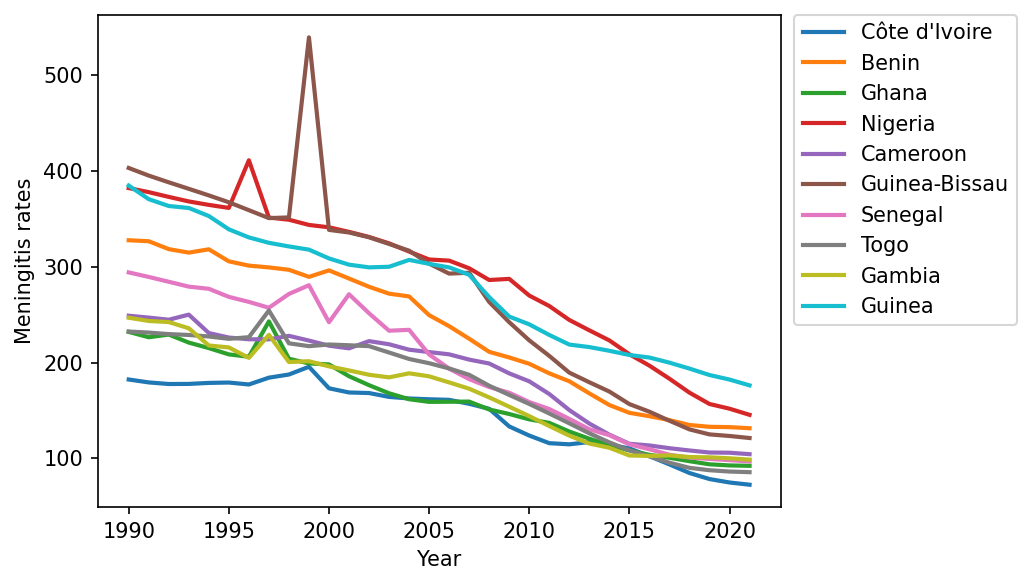

In [34]:
# First, the temperature plot
plt.figure(figsize=(7, 4), dpi=150)

cmap = plt.get_cmap('tab10')

for country_index, country in enumerate(df['location_name'].unique()):
    #print(country_index)
    #print(country)
    #os.mkdir(f'./data/disease/by country/{country}')
    #df_men_rate[df_men_rate['location_name']== country].to_csv(f'./data/disease/by country/{country}/{country}_meningitis_rate.csv')
    meningitis_incident = pd.read_csv(f'./data/disease/by country/{country}/{country}_meningitis_rate.csv')
    meningitis_incident.set_index('year')
    plt.plot(meningitis_incident['year'], meningitis_incident['val'], label=f'{country}', color=cmap(country_index), linestyle='-', linewidth=2)
    #plt.fill_between(meningitis_incident['year'], meningitis_incident['lower'], meningitis_incident['upper'], color=cmap(country_index), linewidth=0, alpha=0.2)


# Add title and labels
plt.xlabel('Year')
plt.ylabel('Meningitis rates')

# Show legend
plt.legend(bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          borderaxespad=0.)

# Adjust layout to avoid label cutoff
plt.tight_layout()

plt.show()  

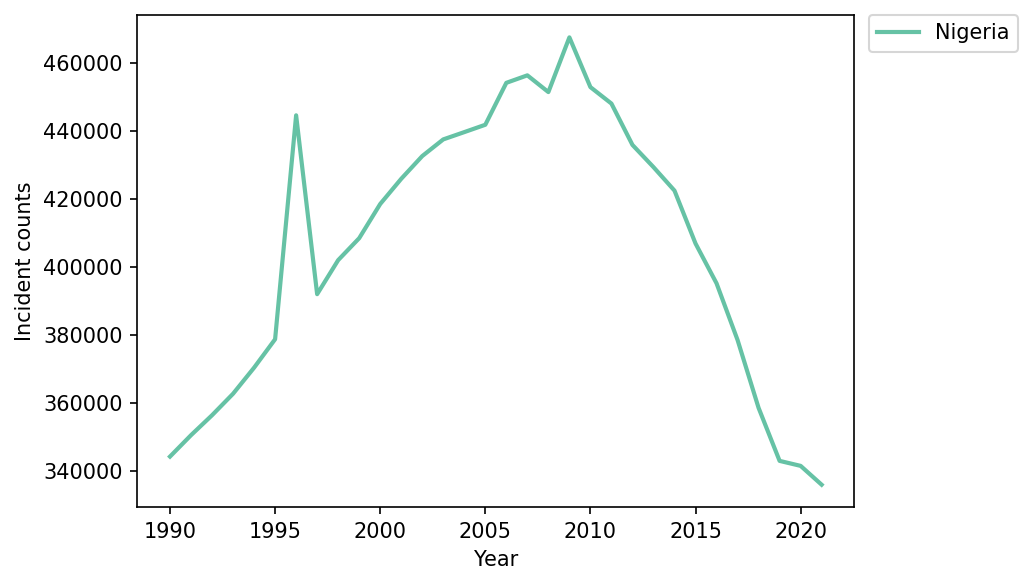

In [ ]:
country_list =['Nigeria']

# First, the temperature plot
plt.figure(figsize=(7, 4), dpi=150)

cmap = plt.get_cmap('Set2')

for country_index, country in enumerate(country_list):
    #print(country_index)
    #print(country)
    os.mkdir(f'./data/disease/by country/{country}')
    # df_men_number[df_men_number['location_name']== country].to_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
    meningitis_incident = pd.read_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
    #meningitis_incident.set_index('year')
    plt.plot(meningitis_incident['year'], meningitis_incident['val'], label=f'{country}', color=cmap(country_index), linestyle='-', linewidth=2)
    
    #plt.fill_between(meningitis_incident['year'], meningitis_incident['lower'], meningitis_incident['upper'], color=cmap(country_index), linewidth=0, alpha=0.2)


# Add title and labels
plt.xlabel('Year')
plt.ylabel('Incident counts')

# Show legend
plt.legend(bbox_to_anchor=(1.02, 1), 
          loc='upper left', 
          borderaxespad=0.)

# Adjust layout to avoid label cutoff
plt.tight_layout()

plt.show()  

## Plotting

In [3]:
Benin_meningitis_incident = pd.read_csv('./data/disease/by country/Benin/Benin_meningitis_incident.csv')
Benin_meningitis_incident.set_index('year')
Benin_meningitis_incident.head()


,Unnamed: 0,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,96,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1990,15901.031310,18563.385113,13408.585090
1,99,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1991,16401.530009,19167.733685,13850.751812
2,102,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1992,16534.989651,19374.458008,13947.833773
3,105,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1993,16897.201663,19873.435804,14273.360617
4,108,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1994,17649.402513,20836.451699,14956.443165


<Axes: xlabel='year'>

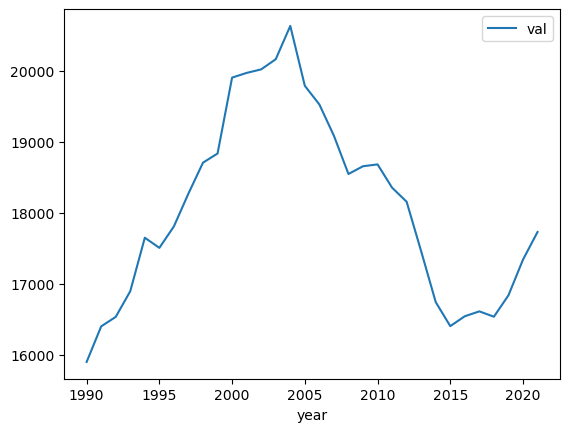

In [49]:
Benin_meningitis_incident.plot(x='year', y='val')

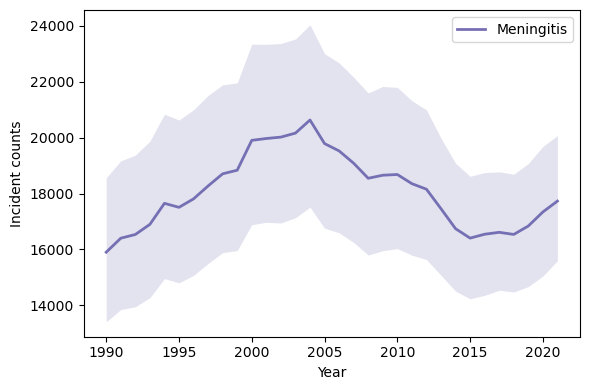

In [ ]:
## Plot monthly climatologies with shading showing min/max for each calendar month
########################################################################################

# First, the temperature plot
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(Benin_meningitis_incident['year'], Benin_meningitis_incident['val'], label='Benin', color='#7570b3', linestyle='-', linewidth=2)
#ax.plot(Benin_meningitis_incident.index, Benin_meningitis_incident['Jaffna'], label='Jaffna', color=color_Jaffna, linestyle='-', linewidth=2)

ax.fill_between(Benin_meningitis_incident['year'], Benin_meningitis_incident['lower'], Benin_meningitis_incident['upper'], color='#7570b3', linewidth=0, alpha=0.2)
# ax.fill_between(Benin_meningitis_incident.index, Benin_meningitis_incident['lower'], Benin_meningitis_incident['upper'], color=Benin_meningitis_incident['val'], linewidth=0, alpha=0.2)

# Add title and labels
ax.set_xlabel('Year')
ax.set_ylabel('Incident counts')

# Show legend
ax.legend()

# Adjust layout to avoid label cutoff
plt.tight_layout()

plt.show()

# Next, the precipitation plot
#fig, ax = plt.subplots(figsize=(6, 4))

#ax.plot(prcp_monthlyClim.index, prcp_monthlyClim['Negombo'], label='Negombo', color=color_Negombo, linestyle='-', linewidth=2)
#ax.plot(prcp_monthlyClim.index, prcp_monthlyClim['Jaffna'], label='Jaffna', color=color_Jaffna, linestyle='-', linewidth=2)

#ax.fill_between(prcp_monthlyClim.index, prcp_monthlyMin['Negombo'], prcp_monthlyMax['Negombo'], color=color_Negombo, linewidth=0, alpha=0.2)
#ax.fill_between(prcp_monthlyClim.index, prcp_monthlyMin['Jaffna'], prcp_monthlyMax['Jaffna'], color=color_Jaffna, linewidth=0, alpha=0.2)

# Add title and labels
#ax.set_xlabel('Month')
#ax.set_ylabel('Precipitation (mm/month)')

# Show legend
#ax.legend()

# Adjust layout to avoid label cutoff
#plt.tight_layout()

#plt.show()

## Correlations

In [19]:
# lets run all the countries all the crop and all the time scales for the SPEI

"""# get sheet names for SPEI data
file_path = 'SPEI_AVG_CROP_ZC.xlsx'
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names"""

# read in the sst data and reshape it
ncdata =  xr.open_dataset('./data/climate/sst.yrmean.nc')
sst = ncdata['sst']
sst_allt = []

# reshape nc file into a 2D array
for t in sst['year'].values:
    sst_allt.append(sst.sel(year = t).values)
sst_allt = np.array(sst_allt)
num_images, height, width  = sst_allt.shape
reshaped_sst = sst_allt.reshape(num_images, height * width).T

# get lon, lat
# Calculate the correlation for each grid cell in SST
latitudes = sst['lat'].values
longitudes = sst['lon'].values

In [26]:
sst

<xarray.DataArray 'sst' (year: 32, lat: 89, lon: 180)>
[512640 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 -178.0 -176.0 -174.0 -172.0 ... 176.0 178.0 180.0
  * year     (year) int64 1990 1991 1992 1993 1994 ... 2017 2018 2019 2020 2021
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

```python
correlation_all_crops = {}
for name in sheet_names:
    spei_country = pd.read_excel('SPEI_AVG_CROP_ZC.xlsx', sheet_name=name)
    spei_country['time'] = pd.to_datetime(spei_country['time'], format='%Y%m')
    
    correlation_maps = {}
    for col in tqdm(spei_country.columns[1:]):
        spei_array  = spei_country[col].values
        
        correlation_map = []
        for i in range(len(reshaped_sst)):
            sst_series = reshaped_sst[i]
        # Ensure valid data for correlation (no NaNs)
            mask = ~np.isnan(spei_array) & ~np.isnan(sst_series)
            if np.sum(mask) > 0:
                correlation_map.append(float(pearsonr(sst_series[mask], spei_array[mask])[0]))
            else:
                correlation_map.append(np.nan)
                
        correlation_map = np.array(correlation_map).reshape((len(latitudes), len(longitudes)))
        correlation_maps[col] = correlation_map
    correlation_all_crops[name] = correlation_maps
```

In [38]:
correlation_all_country = {}
for country in tqdm(df['location_name'].unique()):
    meningitis_incident = pd.read_csv(f'./data/disease/by country/{country}/{country}_meningitis_rate.csv')
    meningitis_incident['year'] = pd.to_datetime(meningitis_incident['year'], format='%Y')
    
    correlation_map = []
    meningitis_array  = meningitis_incident['val'].values
        
    for i in range(len(reshaped_sst)):
        sst_series = reshaped_sst[i]
    # Ensure valid data for correlation (no NaNs)
        mask = ~np.isnan(meningitis_array) & ~np.isnan(sst_series)
        if np.sum(mask) > 0:
            correlation_map.append(float(pearsonr(sst_series[mask], meningitis_array[mask])[0])) 
        else:
            correlation_map.append(np.nan)
                
    correlation_map = np.array(correlation_map).reshape((len(latitudes), len(longitudes)))
    correlation_all_country[country] = correlation_map

100%|██████████| 10/10 [02:03<00:00, 12.37s/it]


In [15]:
country = 'Benin'
meningitis_incident = pd.read_csv(f'./data/disease/by country/{country}/{country}_meningitis_incident.csv')
meningitis_incident['year'] = pd.to_datetime(meningitis_incident['year'], format='%Y')

meningitis_incident.head()

,Unnamed: 0,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,96,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1990-01-01,15901.031310,18563.385113,13408.585090
1,99,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1991-01-01,16401.530009,19167.733685,13850.751812
2,102,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1992-01-01,16534.989651,19374.458008,13947.833773
3,105,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1993-01-01,16897.201663,19873.435804,14273.360617
4,108,6,Incidence,200,Benin,3,Both,22,All ages,332,Meningitis,1,Number,1994-01-01,17649.402513,20836.451699,14956.443165


In [ ]:
correlation_all_country['Senegal']

array([[-0.37460942, -0.3760836 , -0.36706547, ..., -0.29249026,
        -0.33617083, -0.36003743],
       [-0.2089715 , -0.22253049, -0.23723462, ..., -0.20998467,
        -0.20257939, -0.20423709],
       [-0.14445202, -0.1444323 , -0.1480736 , ..., -0.14769889,
        -0.16855687, -0.16419829],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])

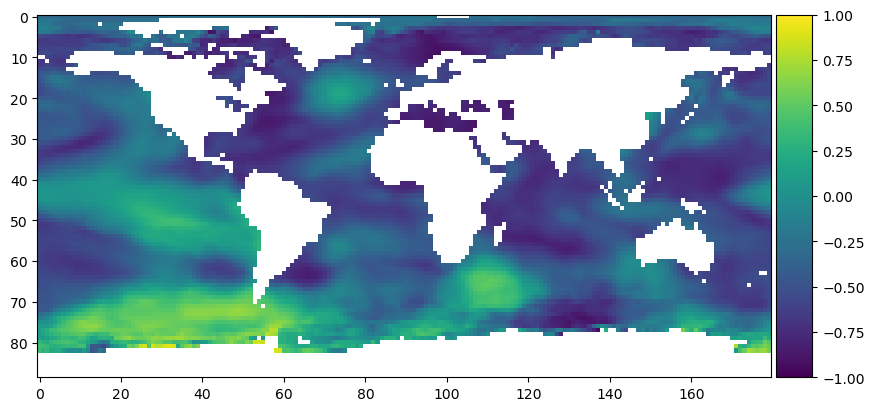

In [42]:
# Create the plot
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(10, 10))

# Display the image using plt.imshow
im = ax.imshow(correlation_all_country['Benin'], cmap='viridis', vmax=1, vmin=-1)

# Create a divider for the existing axes to align the color bar
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)  # Adjust size and padding as needed

# Add the color bar to the new axes, ensuring it fits the image size
plt.colorbar(im, cax=cax)

# Show the plot
plt.show()

In [43]:
masked_data = {
    country: np.where((data > 0.4) | (data < -0.4), data, np.nan)
    for country, data in correlation_all_country.items()
}


In [ ]:
# Determine the grid size for subplots
n_countries = len(df['location_name'].unique())
cols = 3  # Number of columns in the grid
rows = (n_countries + cols - 1) // cols  # Calculate rows needed

fig, axes = plt.subplots(4, 3, figsize=(15, 5*rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Loop through each country and plot
for i, country in enumerate(df['location_name'].unique()):
    ax = axes[i]
    im = ax.imshow(correlation_all_country[country], cmap='viridis', vmax=1, vmin=-1)
    ax.set_title(country)  # Add title for each subplot
    ax.axis('off')  # Optional: Turn off the axis for a cleaner look

# Remove unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Add a shared colorbar
fig.subplots_adjust(right=0.85)  # Adjust space for the colorbar
cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])  # Position: [left, bottom, width, height]
fig.colorbar(im, cax=cbar_ax)


# Adjust spacing between subplots
fig.subplots_adjust(
    wspace=0.2,  # Reduce horizontal space between subplots
    hspace=0.3,  # Reduce vertical space between subplots
    left=0.05,   # Adjust left margin
    right=0.85,  # Make space for the colorbar
    top=0.9,     # Adjust top margin
    bottom=0.1   # Adjust bottom margin
)

plt.show()


In [ ]:
plt.figure(figsize=(14, 8), dpi=180)


# Because our lon and lat variables are 1D,
# use meshgrid to create 2D arrays
# Not necessary if coordinates are already in 2D arrays.
lon, lat = np.meshgrid(lons, lats)
xi, yi = m(lon, lat)

# Plot Data
cs = m.pcolor(xi,yi,np.squeeze(anomaly['sst'].sel(year=2015)), cmap='coolwarm')

# Add Grid Lines
m.drawparallels(np.arange(-80., 81., 10.), labels=[1,0,0,0], fontsize=10)
#m.drawmeridians(np.arange(-180., 181., 10.), labels=[0,0,0,1], fontsize=10)

# Add Coastlines, States, and Country Boundaries
#m.drawcoastlines()
#m.drawstates()
m.drawcountries()

# Add Colorbar
cbar = m.colorbar(cs, location='bottom', pad="10%")
cbar.set_label(unit)



plt.show()